In [48]:
# SOFTWARE DEFECT PREDICTION: STEP EDA & BALANCED MODELING
# =============================================================================
# 1. Strategic EDA Visualizations
# 2. Manual Random Oversampling for Class Balance
# 3. Before vs. After Balancing Comparison
# 4. Model Training: Logistic Regression & Decision Tree
# 5. Professional Rank Table
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import warnings

# --- Global Style Setup ---
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [49]:
# -----------------------------------------------------------------------------
# STEP 1: DATA LOADING
# -----------------------------------------------------------------------------
try:
    df = pd.read_csv('software_defect_prediction_dataset (1).csv')
    print("✓ Dataset loaded successfully.")
except Exception as e:
    print(f"Error: {e}. Ensure the CSV is uploaded.")

✓ Dataset loaded successfully.


In [50]:
df.head()

,lines_of_code,cyclomatic_complexity,num_functions,num_classes,comment_density,code_churn,developer_experience_years,num_developers,commit_frequency,bug_fix_commits,...,avg_function_length,depth_of_inheritance,response_for_class,coupling_between_objects,lack_of_cohesion,build_failures,static_analysis_warnings,security_vulnerabilities,performance_issues,defect
0,910,12,7,79,0.59,539,19,4,23,7,...,70,1,54,27,0.06,3,20,31,21,1
1,3822,9,197,72,0.30,584,8,8,126,153,...,180,5,73,23,0.39,9,154,38,29,1
2,3142,20,99,92,0.11,593,0,6,272,177,...,152,5,9,31,0.08,7,425,22,6,1
3,516,39,52,79,0.18,81,12,14,16,0,...,159,9,23,12,0.44,2,339,24,12,1
4,4476,27,162,75,0.21,918,14,1,164,109,...,169,2,84,9,0.41,3,111,19,2,1


In [51]:
df.tail()

,lines_of_code,cyclomatic_complexity,num_functions,num_classes,comment_density,code_churn,developer_experience_years,num_developers,commit_frequency,bug_fix_commits,...,avg_function_length,depth_of_inheritance,response_for_class,coupling_between_objects,lack_of_cohesion,build_failures,static_analysis_warnings,security_vulnerabilities,performance_issues,defect
59995,3521,4,45,93,0.49,742,0,4,237,0,...,186,9,43,18,0.41,12,215,29,1,1
59996,4286,26,194,79,0.17,878,16,12,179,74,...,86,4,59,45,0.62,3,4,31,4,1
59997,919,46,119,42,0.03,649,1,5,194,42,...,9,1,16,18,0.93,13,207,36,5,1
59998,3127,10,120,22,0.25,971,5,11,268,141,...,38,1,34,48,0.22,0,117,6,16,1
59999,3863,27,119,18,0.58,690,16,6,196,17,...,137,9,57,39,0.83,0,102,11,11,1


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   lines_of_code               60000 non-null  int64  
 1   cyclomatic_complexity       60000 non-null  int64  
 2   num_functions               60000 non-null  int64  
 3   num_classes                 60000 non-null  int64  
 4   comment_density             60000 non-null  float64
 5   code_churn                  60000 non-null  int64  
 6   developer_experience_years  60000 non-null  int64  
 7   num_developers              60000 non-null  int64  
 8   commit_frequency            60000 non-null  int64  
 9   bug_fix_commits             60000 non-null  int64  
 10  past_defects                60000 non-null  int64  
 11  test_coverage               60000 non-null  float64
 12  duplication_percentage      60000 non-null  float64
 13  avg_function_length         600


Generating  Exploratory Visualizations...


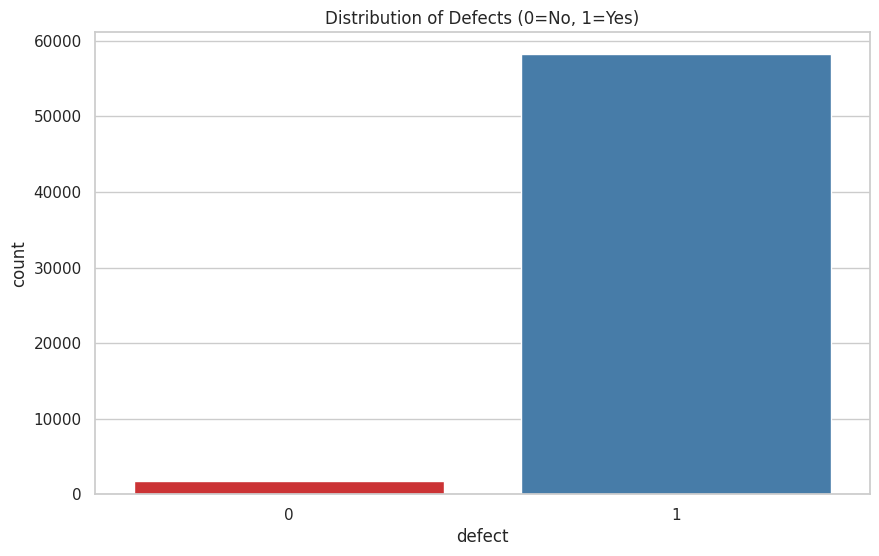

In [53]:
print("\nGenerating  Exploratory Visualizations...")

# 1. Defect Count (The Imbalance Problem)
plt.figure()
sns.countplot(x='defect', data=df, palette='Set1')
plt.title('Distribution of Defects (0=No, 1=Yes)')
plt.show()

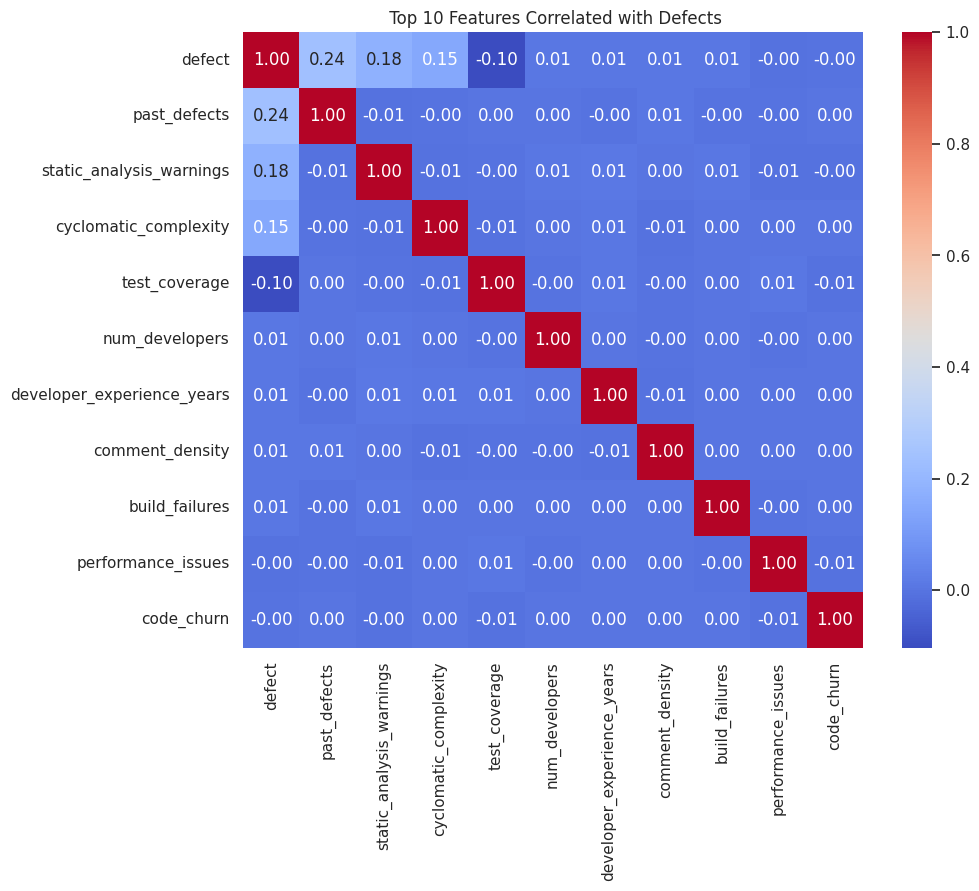

In [54]:
# 2. Correlation Heatmap (Top 10 Metrics)
plt.figure(figsize=(10, 8))
top_corr = df.corr()['defect'].abs().sort_values(ascending=False).head(11).index
sns.heatmap(df[top_corr].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title(' Top 10 Features Correlated with Defects')
plt.show()

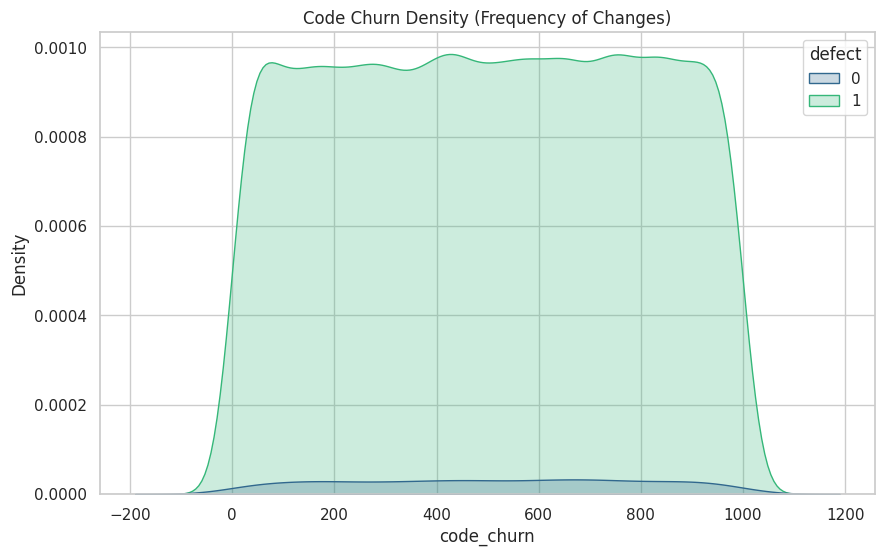

In [55]:
# 4. Code Churn Density
plt.figure()
sns.kdeplot(data=df, x='code_churn', hue='defect', fill=True, palette='viridis')
plt.title('Code Churn Density (Frequency of Changes)')
plt.show()

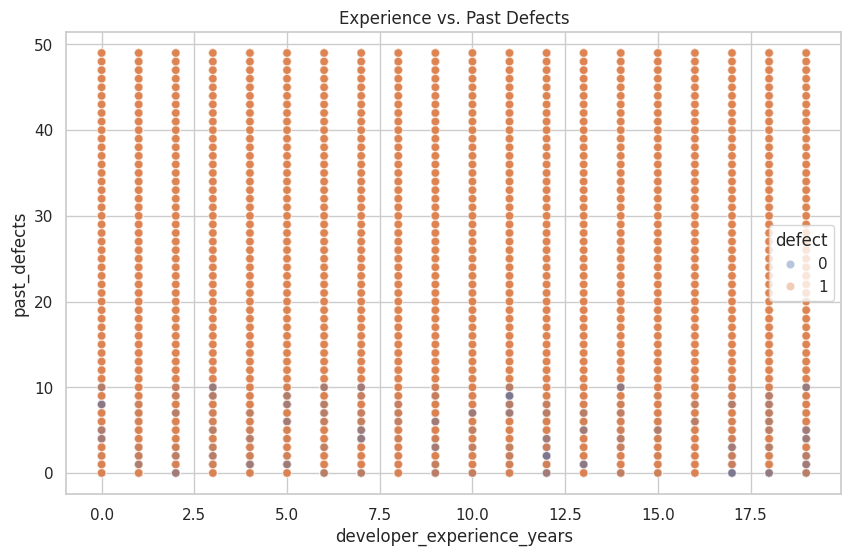

In [56]:
# 5. Developer Experience vs Past Defects
plt.figure()
sns.scatterplot(x='developer_experience_years', y='past_defects', hue='defect', data=df, alpha=0.4)
plt.title('Experience vs. Past Defects')
plt.show()

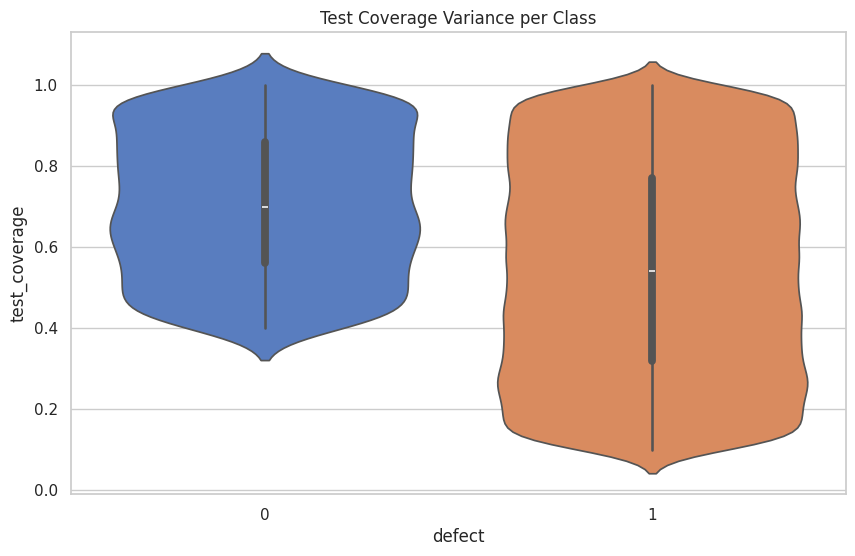

In [57]:
# 6. Test Coverage Distribution
plt.figure()
sns.violinplot(x='defect', y='test_coverage', data=df, palette='muted')
plt.title('Test Coverage Variance per Class')
plt.show()

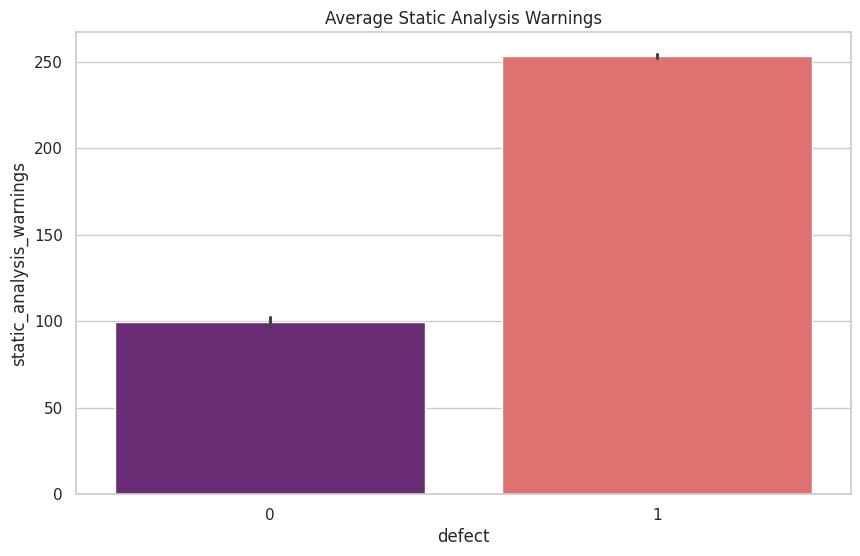

In [58]:
# 7. Static Analysis Warnings
plt.figure()
sns.barplot(x='defect', y='static_analysis_warnings', data=df, palette='magma')
plt.title('Average Static Analysis Warnings')
plt.show()

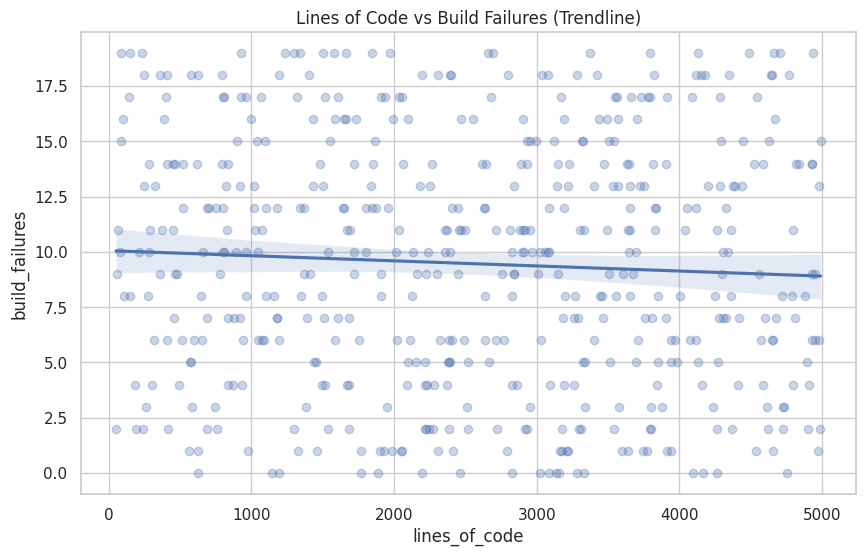

In [59]:
# 8. Lines of Code (LoC) vs Build Failures
plt.figure()
sns.regplot(x='lines_of_code', y='build_failures', data=df.sample(500), scatter_kws={'alpha':0.3})
plt.title('Lines of Code vs Build Failures (Trendline)')
plt.show()

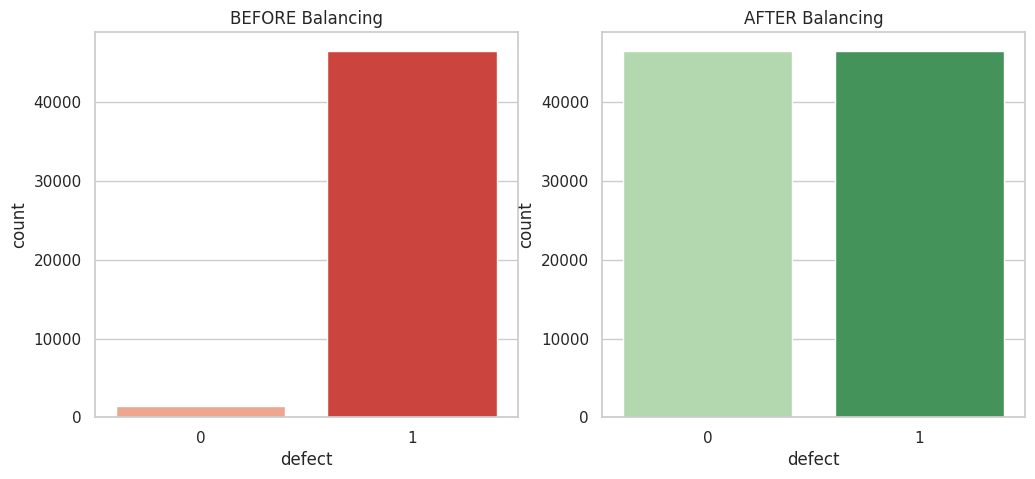

In [60]:
# -----------------------------------------------------------------------------
# STEP 3: OVERSAMPLING & BALANCING COMPARISON
# -----------------------------------------------------------------------------
X = df.drop('defect', axis=1)
y = df['defect']

# Split first to keep test data pure
X_train_raw, X_test, y_train_raw, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Manual Oversampling
train_data = pd.concat([X_train_raw, y_train_raw], axis=1)
df_majority = train_data[train_data.defect == 1]
df_minority = train_data[train_data.defect == 0]

df_minority_upsampled = resample(df_minority, replace=True, n_samples=len(df_majority), random_state=42)
train_balanced = pd.concat([df_majority, df_minority_upsampled])

# Visualize Comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x='defect', data=train_data, ax=ax1, palette='Reds')
ax1.set_title('BEFORE Balancing')
sns.countplot(x='defect', data=train_balanced, ax=ax2, palette='Greens')
ax2.set_title('AFTER Balancing')
plt.show()

X_train_final = train_balanced.drop('defect', axis=1)
y_train_final = train_balanced['defect']

In [61]:
# -----------------------------------------------------------------------------
# STEP 4: MODEL TRAINING (LOGISTIC REGRESSION & DECISION TREE)
# -----------------------------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train_final)
    preds = model.predict(X_test_scaled)

    results.append({
        "Algorithm": name,
        "Accuracy": round(accuracy_score(y_test, preds), 4),
        "Precision": round(precision_score(y_test, preds), 4),
        "Recall": round(recall_score(y_test, preds), 4),
        "F1-Score": round(f1_score(y_test, preds), 4)
    })


SOFTWARE DEFECT PREDICTION RANK TABLE
                Algorithm  Accuracy  Precision  Recall  F1-Score
Rank                                                            
1           Decision Tree    1.0000     1.0000  1.0000    1.0000
2     Logistic Regression    0.9333     0.9994  0.9317    0.9644


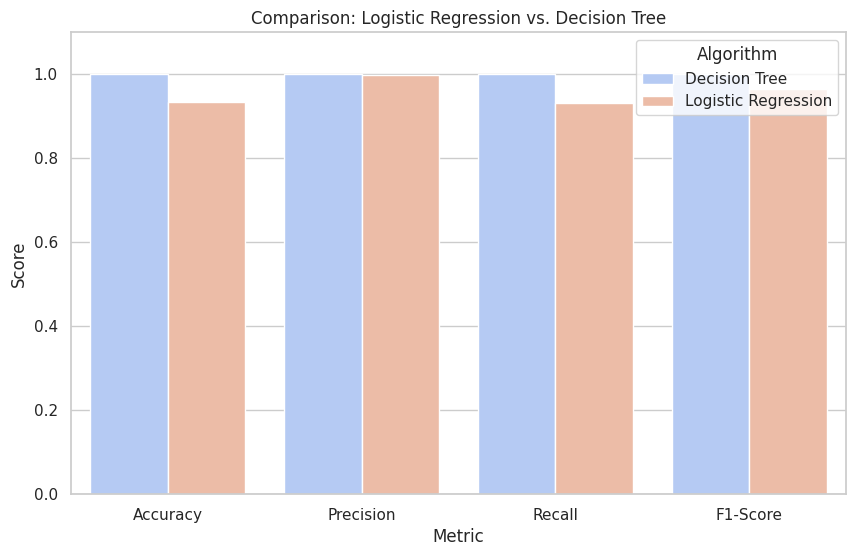

In [62]:
# -----------------------------------------------------------------------------
# STEP 5: RANK TABLE & EVALUATION
# -----------------------------------------------------------------------------
rank_table = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False).reset_index(drop=True)
rank_table.index += 1
rank_table.index.name = "Rank"

print("\n" + "="*50)
print("SOFTWARE DEFECT PREDICTION RANK TABLE")
print("="*50)
print(rank_table)

# Performance Plot
plt.figure()
plot_data = rank_table.melt(id_vars='Algorithm', var_name='Metric', value_name='Score')
sns.barplot(x='Metric', y='Score', hue='Algorithm', data=plot_data, palette='coolwarm')
plt.title('Comparison: Logistic Regression vs. Decision Tree')
plt.ylim(0, 1.1)
plt.show()

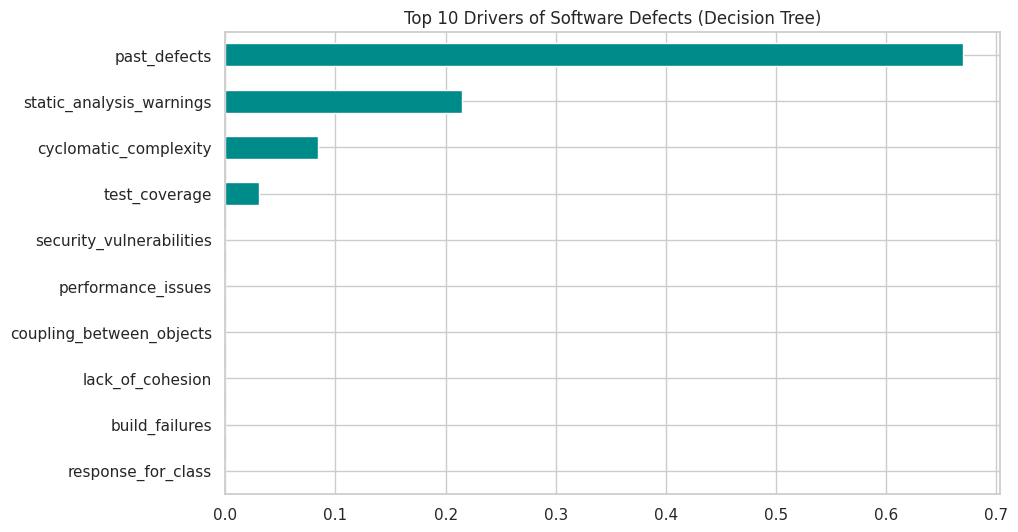

In [63]:
# Feature Importance from Best Model
plt.figure()
best_model = models["Decision Tree"]
feat_importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=True).tail(10)
feat_importances.plot(kind='barh', color='darkcyan')
plt.title('Top 10 Drivers of Software Defects (Decision Tree)')
plt.show()